In [1]:
import numpy as np
import matplotlib.pyplot as plt
 
import pandas as pd
import seaborn as sns
 

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r"D:\Shubham\EDA\student_habits_performance.csv")
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [4]:
df.isnull().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [3]:
df['parental_education_level'] = df['parental_education_level'].fillna('No Information')

In [7]:
df.duplicated().sum()           ##it means there is no duplicate records.

np.int64(0)

In [4]:
def detect_outliers(df, method = 'IQR', threshold = 3):
    numeric_df = df.select_dtypes(include = [np.number])

    if method == 'Z':
        z_score = np.abs((numeric_df - numeric_df.mean()) / numeric_df.std())
        return (z_score > threshold)
    elif method == 'IQR':
        Q1 = numeric_df.quantile(0.25)
        Q3 = numeric_df.quantile(0.75)

        IQR = Q3 - Q1
        return ((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR)))

In [10]:
has_outliers = outliers.any().any()
print(has_outliers)                     # it means there is some column in which outliers are present

True


In [11]:
outlier_columns = outliers.any(axis=0)
print(f'Columns with Outliers: \n\n{outlier_columns}')

Columns with Outliers: 

age                      False
study_hours_per_day       True
social_media_hours        True
netflix_hours             True
attendance_percentage    False
sleep_hours              False
exercise_frequency       False
mental_health_rating     False
exam_score                True
dtype: bool


<Axes: xlabel='exam_score'>

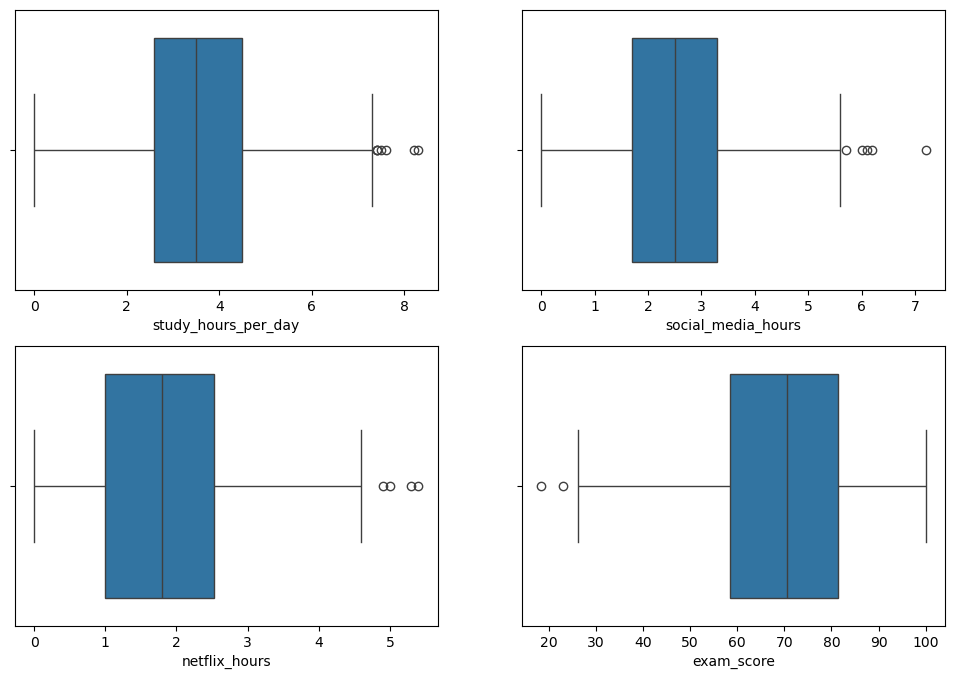

In [12]:
fig = plt.figure(figsize =(12,8))
plt.subplot(2,2,1)
sns.boxplot(data=df, x=df['study_hours_per_day'])
plt.subplot(2,2,2)
sns.boxplot(data=df, x=df['social_media_hours'])
plt.subplot(2,2,3)
sns.boxplot(data=df, x=df['netflix_hours'])
plt.subplot(2,2,4)
sns.boxplot(data=df, x=df['exam_score'])

In [5]:
treat_columns = ['study_hours_per_day','social_media_hours','netflix_hours','exam_score']
# i know it's not needed to treat outliers in these columns but still i wanna try it for my learning.
for i in treat_columns:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    df[i] = np.clip(df[i], lower_bound, upper_bound)


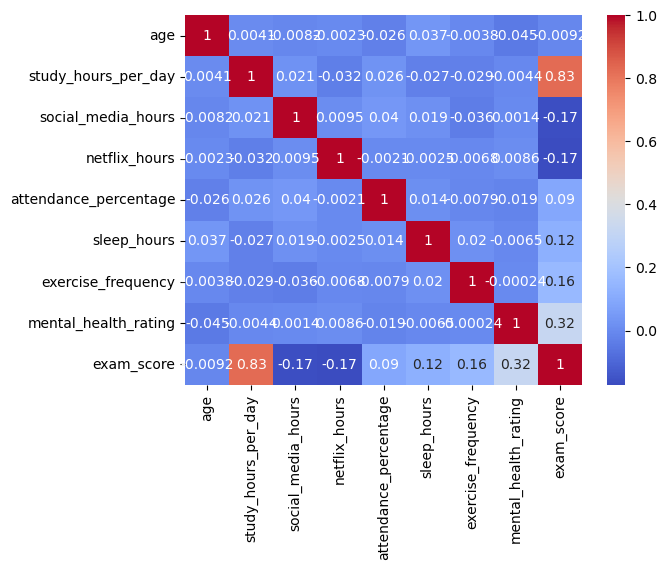

In [16]:
numeric_df = df.select_dtypes(include = [np.number])

corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [18]:
from scipy import stats

In [19]:
# Null hypothesis: Student's average sleep hours is 8 hours.
# Alternate hypothesis: There is significant difference in student's average sleep hours.

t_stat, p_val = stats.ttest_1samp(df['sleep_hours'], 8)
print(f'T-statistics: {t_stat}')
print(f'P-value: {p_val}')

T-statistics: -39.44928424756235
P-value: 6.022331095644453e-206


In [20]:
# We reject the null hypothesis.

In [21]:
# Null hypothesis: Average exam score's of male and female students are similar.
# Alternate hypothesis: Average exam score's of male and female students are different.

male_exam_score = df[df['gender'] == 'Male']['exam_score']
female_exam_score = df[df['gender'] == 'Female']['exam_score']

t_stat, p_val = stats.ttest_ind(male_exam_score, female_exam_score, equal_var=False)
print(f'T-statistics: {t_stat} \nP-value: {p_val}')

T-statistics: -0.34833752420180253 
P-value: 0.7276634550734136


In [22]:
# We failed to reject the null hypothesis.

In [23]:
# Null hypothesis: There is no relation between Part time job and Extracurricular participation.
# Alternate hypothesis: There is significant relation between Part time job and Extracurricular participation.

crosstab = pd.crosstab(df['part_time_job'], df['extracurricular_participation'])
chi2, p_val, dof, expected = stats.chi2_contingency(crosstab)
print(f'Chi2 Value: {chi2} \nP-value: {p_val} \nDegree of Freedom: {dof}')

Chi2 Value: 0.40916861941010035 
P-value: 0.5223917831673718 
Degree of Freedom: 1


In [24]:
# We failed to reject the null hypothesis.

In [25]:
from scipy.stats import f_oneway

In [26]:
# Null hypothesis: The average marks of all students having different level of internet quality is same
# Alternate hypothesis: Significant difference in exam marks.
groups = [df[df['internet_quality'] == level]['exam_score']
          for level in df['internet_quality'].unique()]

f_stat, p_val = stats.f_oneway(*groups)
print(f'F-statistics: {f_stat} \nP-value: {p_val}')

F-statistics: 1.447420269550133 
P-value: 0.23566994314451004


In [27]:
# We failed to reject the null hypothesis.

In [6]:
categorical_field = df.select_dtypes(exclude=np.number).columns
print(categorical_field)

Index(['student_id', 'gender', 'part_time_job', 'diet_quality',
       'parental_education_level', 'internet_quality',
       'extracurricular_participation'],
      dtype='object')


In [7]:
le = LabelEncoder()
for i in categorical_field.drop('student_id'):
    df[i] = le.fit_transform(df[i])

In [8]:
df_copy = df.copy()
df_copy.drop('student_id',axis=1, inplace=True)

In [38]:
df_copy.head()

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,0,0.0,1.2,1.1,0,85.0,8.0,0,6,2,0,8,1,56.2
1,20,0,6.9,2.8,2.3,0,97.3,4.6,1,6,1,0,8,0,100.0
2,21,1,1.4,3.1,1.3,0,94.8,8.0,2,1,1,2,1,0,34.3
3,23,0,1.0,3.9,1.0,0,71.0,9.2,2,4,2,1,1,1,26.8
4,19,0,5.0,4.4,0.5,0,90.9,4.9,0,3,2,1,1,0,66.4


In [9]:
# Splitting our data for training and testing
x = df_copy.drop(['exam_score','age','gender'], axis=1)
y = df_copy[['exam_score']]

x_train, x_test, y_train, y_test = train_test_split(x,  y, test_size=0.2, random_state=30)

In [10]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [11]:
model.coef_

array([[ 9.50408716, -2.56722987, -2.25004472,  0.18459141,  0.13770992,
         2.00224417,  0.03806788,  1.47225842, -0.22875967, -0.12372669,
         1.94909591,  0.12669347]])

In [12]:
model.intercept_

array([7.14927901])

In [13]:
# Evaluation of the Model

In [14]:
y_pred = model.predict(x_test)

In [45]:
print(f'R2 Score: {r2_score(y_test, y_pred)}')

R2 Score: 0.9233007302718218


In [49]:
# Mean Squared Error(MSE)
mean_squared_error(y_test, y_pred)

24.36003917575139

In [51]:
# Root Mean Squared Error(RMSE)
np.sqrt(mean_squared_error(y_test, y_pred))

np.float64(4.935589040403525)

In [52]:
dict(zip(x_train.columns, model.coef_[0]))

{'study_hours_per_day': np.float64(9.504087162839133),
 'social_media_hours': np.float64(-2.5672298731964194),
 'netflix_hours': np.float64(-2.2500447152945813),
 'part_time_job': np.float64(0.1845914093322108),
 'attendance_percentage': np.float64(0.13770991640371638),
 'sleep_hours': np.float64(2.002244174820877),
 'diet_quality': np.float64(0.038067877340834735),
 'exercise_frequency': np.float64(1.47225841563405),
 'parental_education_level': np.float64(-0.2287596688117409),
 'internet_quality': np.float64(-0.12372669275516235),
 'mental_health_rating': np.float64(1.9490959073840493),
 'extracurricular_participation': np.float64(0.12669347166680858)}

In [55]:
import statsmodels.api as sm
x_ols = sm.add_constant(x)
ols_model = sm.OLS(y, x_ols).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     769.0
Date:                Wed, 07 Jan 2026   Prob (F-statistic):               0.00
Time:                        20:24:15   Log-Likelihood:                -3075.5
No. Observations:                1000   AIC:                             6177.
Df Residuals:                     987   BIC:                             6241.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         